# Intelligent Air Quality Forecasting and Pollution Risk Analysis Using Machine Learning
 
### Manushi Paudel

This notebook builds a complete machine learning workflow to analyze and forecast air pollution using the **Beijing PM2.5 dataset**. It includes:

- data cleaning and preprocessing  
- exploratory data analysis  
- feature engineering  
- **regression** for PM2.5 prediction  
- **classification** for pollution risk analysis  
- model comparison and interpretation  
- final conclusions and future improvements


## 1. Problem Statement

Air pollution has major environmental and health impacts, especially in urban areas. Among air pollutants, **PM2.5** is one of the most dangerous because fine particles can enter the lungs and bloodstream.

The goal of this project is to:

1. **Predict PM2.5 concentration** using meteorological features  
2. **Classify pollution risk levels** based on PM2.5 thresholds  
3. Understand how factors such as temperature, pressure, dew point, and wind affect air quality


## 2. Dataset

**Dataset:** Beijing PM2.5 Dataset  
**File name:** `PRSA_data_2010.1.1-2014.12.31.csv`




In [48]:
#  Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [49]:
# 4. Load Dataset

DATA_PATH = "PRSA_data_2010.1.1-2014.12.31.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## 3. Initial Data Inspection

We first inspect the structure of the dataset, column names, missing values, and data types.


In [50]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.4 MB


In [51]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,43824.0,NaN,NaN,NaN,21912.5,12651.043435,1.0,10956.75,21912.5,32868.25,43824.0
year,43824.0,NaN,NaN,NaN,2012.0,1.413842,2010.0,2011.0,2012.0,2013.0,2014.0
month,43824.0,NaN,NaN,NaN,6.523549,3.448572,1.0,4.0,7.0,10.0,12.0
day,43824.0,NaN,NaN,NaN,15.72782,8.799425,1.0,8.0,16.0,23.0,31.0
hour,43824.0,NaN,NaN,NaN,11.5,6.922266,0.0,5.75,11.5,17.25,23.0
pm2.5,41757.0,NaN,NaN,NaN,98.613215,92.050387,0.0,29.0,72.0,137.0,994.0
DEWP,43824.0,NaN,NaN,NaN,1.817246,14.43344,-40.0,-10.0,2.0,15.0,28.0
TEMP,43824.0,NaN,NaN,NaN,12.448521,12.198613,-19.0,2.0,14.0,23.0,42.0
PRES,43824.0,NaN,NaN,NaN,1016.447654,10.268698,991.0,1008.0,1016.0,1025.0,1046.0
cbwd,43824,4,SE,15290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
missing = df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values")
missing["Missing Percentage"] = (missing["Missing Values"] / len(df) * 100).round(2)
missing


,Missing Values,Missing Percentage
pm2.5,2067,4.72
No,0,0.00
year,0,0.00
month,0,0.00
day,0,0.00
hour,0,0.00
DEWP,0,0.00
TEMP,0,0.00
PRES,0,0.00
cbwd,0,0.00


## 4. Data Cleaning and Preprocessing

In this section:

- create a proper datetime column  
- remove unnecessary index columns if present  
- handle missing target values  
- keep both numerical and categorical predictors  
- engineer useful time-based features


In [53]:
# Drop unnecessary colum
if "No" in df.columns:
    df = df.drop(columns=["No"])

# Create datetime column 
date_parts = ["year", "month", "day", "hour"]
if all(col in df.columns for col in date_parts):
    df["date"] = pd.to_datetime(df[date_parts])

# Remove rows where target is missing
df = df[df["pm2.5"].notna()].copy()

# Feature engineering :Time Based
if "month" in df.columns:
    df["season"] = df["month"] % 12 // 3 + 1
    df["season_name"] = df["season"].map({1: "Winter", 2: "Spring", 3: "Summer", 4: "Autumn"})

if "hour" in df.columns:
    df["time_of_day"] = pd.cut(
        df["hour"],
        bins=[-1, 5, 11, 17, 23],
        labels=["Night", "Morning", "Afternoon", "Evening"]
    )

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (41757, 16)


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,date,season,season_name,time_of_day
24,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0,2010-01-02 00:00:00,1,Winter,Night
25,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0,2010-01-02 01:00:00,1,Winter,Night
26,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,2010-01-02 02:00:00,1,Winter,Night
27,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0,2010-01-02 03:00:00,1,Winter,Night
28,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0,2010-01-02 04:00:00,1,Winter,Night


## 5. Exploratory Data Analysis

EDA helps reveal the distribution of PM2.5 and its relationship with environmental features.


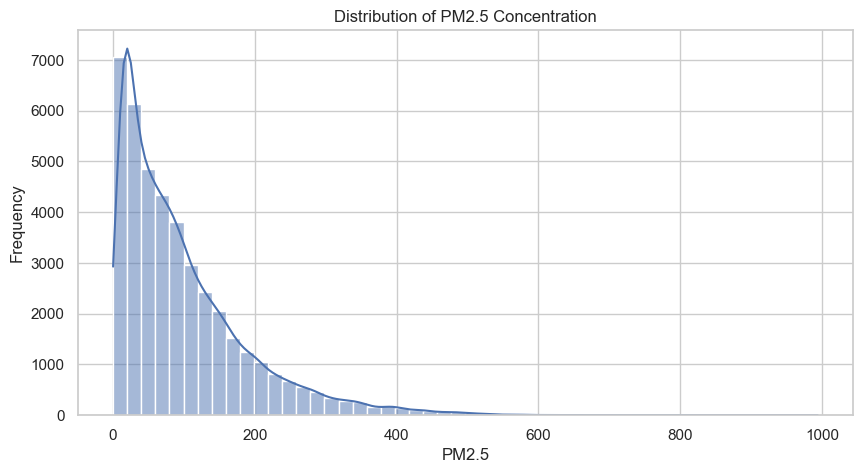

In [54]:
# PM2.5 distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["pm2.5"], bins=50, kde=True)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()


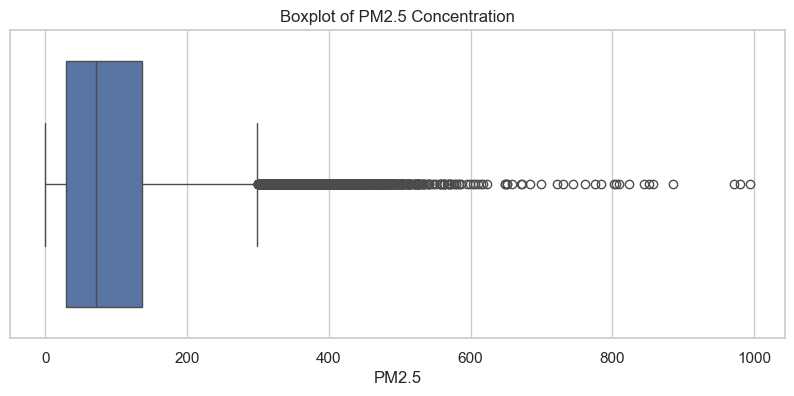

In [55]:
# Boxplot for PM2.5
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["pm2.5"])
plt.title("Boxplot of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.show()


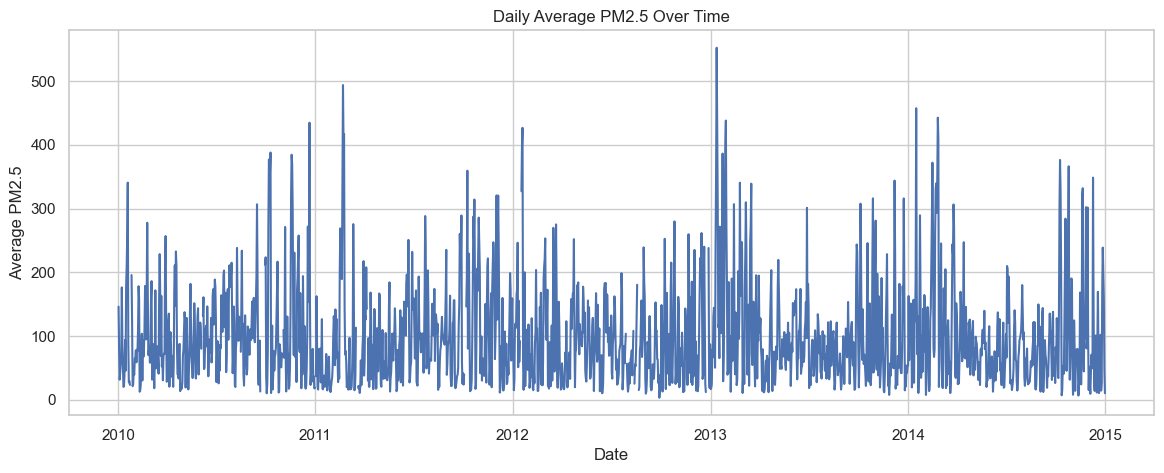

In [56]:
# PM2.5 trend over time
if "date" in df.columns:
    daily_pm = df.set_index("date")["pm2.5"].resample("D").mean()
    plt.figure(figsize=(14, 5))
    plt.plot(daily_pm.index, daily_pm.values)
    plt.title("Daily Average PM2.5 Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average PM2.5")
    plt.show()
else:
    print("Date column not available.")


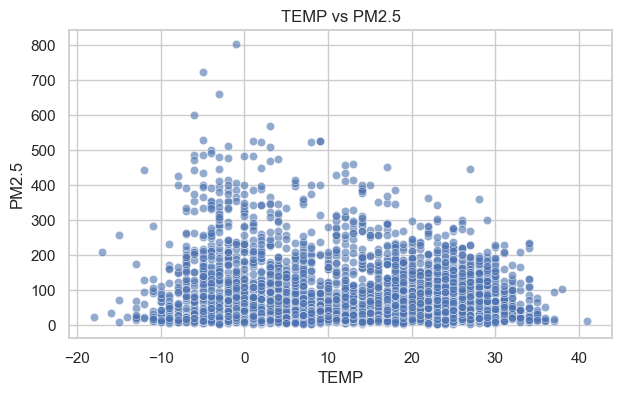

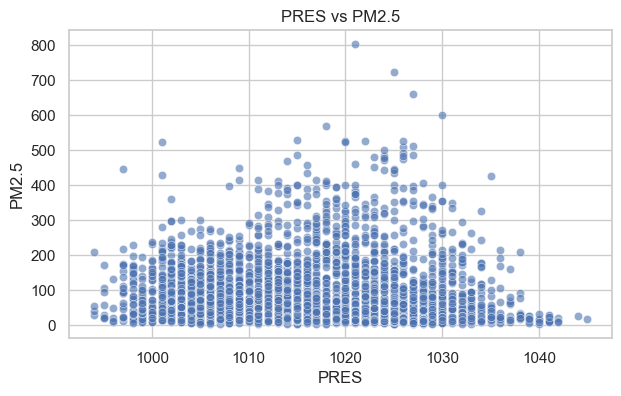

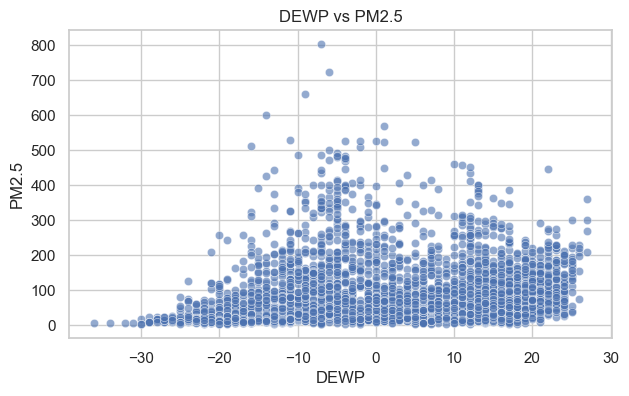

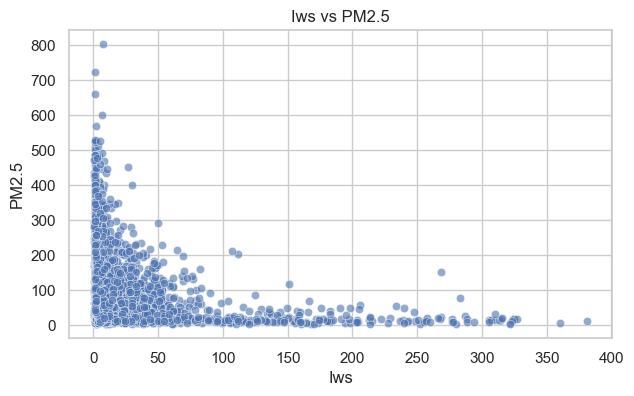

In [58]:
# Scatterplots with PM2.5
candidate_features = [col for col in ["TEMP", "PRES", "DEWP", "Iws"] if col in df.columns]

for col in candidate_features:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42), x=col, y="pm2.5", alpha=0.6)
    plt.title(f"{col} vs PM2.5")
    plt.xlabel(col)
    plt.ylabel("PM2.5")
    plt.show()


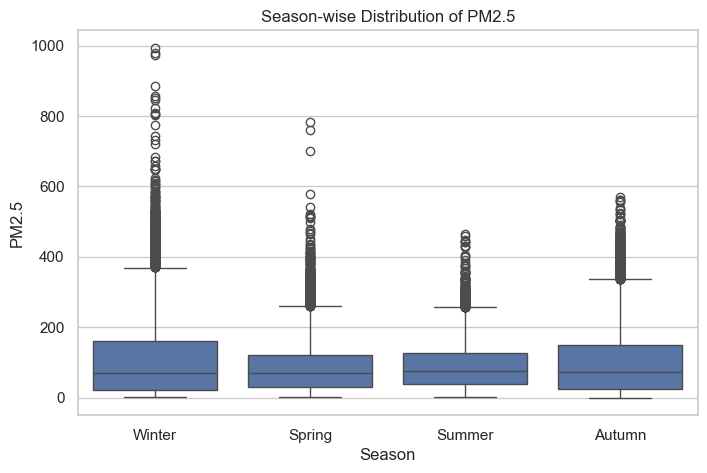

In [59]:
# Seasonal PM2.5 analysis
if "season_name" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="season_name", y="pm2.5", order=["Winter", "Spring", "Summer", "Autumn"])
    plt.title("Season-wise Distribution of PM2.5")
    plt.xlabel("Season")
    plt.ylabel("PM2.5")
    plt.show()
else:
    print("Season feature not available.")


### Key Observations

- PM2.5 values are often highly variable and may include significant outliers.  
- Environmental variables such as dew point, pressure, temperature, and wind speed may influence PM2.5 differently.  
- Seasonal patterns can reveal periods of consistently higher or lower pollution.


## 6. Pollution Risk Label Creation

To support risk analysis, PM2.5 values are grouped into pollution categories. These thresholds are simplified for this project.


In [60]:
def pollution_risk(pm):
    if pm <= 50:
        return "Low"
    elif pm <= 100:
        return "Moderate"
    elif pm <= 150:
        return "High"
    else:
        return "Very High"

df["risk"] = df["pm2.5"].apply(pollution_risk)
df["risk"].value_counts()


risk
Low          15945
Moderate     10445
Very High     8991
High          6376
Name: count, dtype: int64

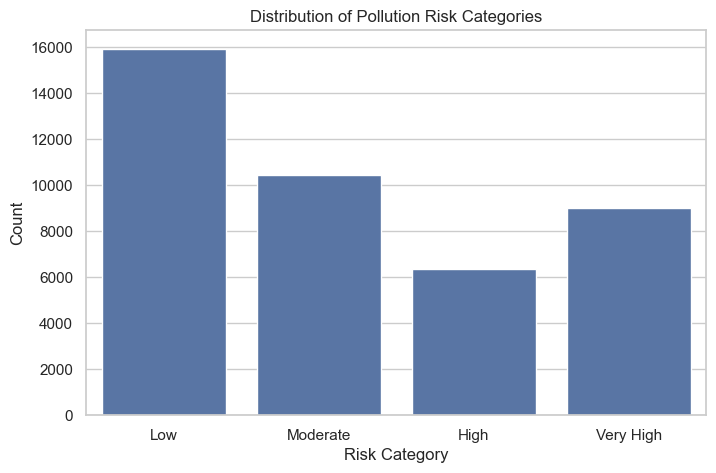

In [61]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="risk", order=["Low", "Moderate", "High", "Very High"])
plt.title("Distribution of Pollution Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()


## 7. Feature Selection

We use both meteorological and contextual features, depending on availability in the dataset.

- Numerical candidates: `DEWP`, `TEMP`, `PRES`, `Iws`, `Is`, `Ir`, `year`, `month`, `day`, `hour`
- Categorical candidates: `cbwd`, `season_name`, `time_of_day`


In [75]:
target_reg = "pm2.5"
target_clf = "risk"

numeric_features = [col for col in ["DEWP", "TEMP", "PRES", "Iws", "Is", "Ir", "year", "month", "day", "hour"] if col in df.columns]
categorical_features = [col for col in ["cbwd", "season_name", "time_of_day"] if col in df.columns]

selected_features = numeric_features + categorical_features

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total selected features:", selected_features)


Numerical features: ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'year', 'month', 'day', 'hour']
Categorical features: ['cbwd', 'season_name', 'time_of_day']
Total selected features: ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'year', 'month', 'day', 'hour', 'cbwd', 'season_name', 'time_of_day']


## 8. Train-Test Split and Preprocessing Pipeline

We prepare reusable preprocessing steps:

- impute missing values  
- scale numerical features  
- one-hot encode categorical variables


In [63]:
X = df[selected_features].copy()
y_reg = df[target_reg].copy()
y_clf = df[target_clf].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 9. Regression Models for PM2.5 Forecasting

We compare:

1. **Linear Regression**  
2. **Random Forest Regressor**


In [64]:
# Linear Regression pipeline
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train_reg, y_train_reg)
y_pred_lr = lr_model.predict(X_test_reg)

lr_mae = mean_absolute_error(y_test_reg, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
lr_r2 = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression Results")
print("MAE :", round(lr_mae, 3))
print("RMSE:", round(lr_rmse, 3))
print("R2  :", round(lr_r2, 3))


Linear Regression Results
MAE : 55.182
RMSE: 77.702
R2  : 0.315


In [65]:
# Random Forest Regressor pipeline
rf_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg_model.fit(X_train_reg, y_train_reg)
y_pred_rf = rf_reg_model.predict(X_test_reg)

rf_mae = mean_absolute_error(y_test_reg, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
rf_r2 = r2_score(y_test_reg, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R2  :", round(rf_r2, 3))


Random Forest Regressor Results
MAE : 23.537
RMSE: 39.304
R2  : 0.825


In [66]:
# Regression model comparison table
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
}).sort_values(by="R2 Score", ascending=False)

regression_results


,Model,MAE,RMSE,R2 Score
1,Random Forest Regressor,23.536673,39.304457,0.824679
0,Linear Regression,55.182478,77.701530,0.314814


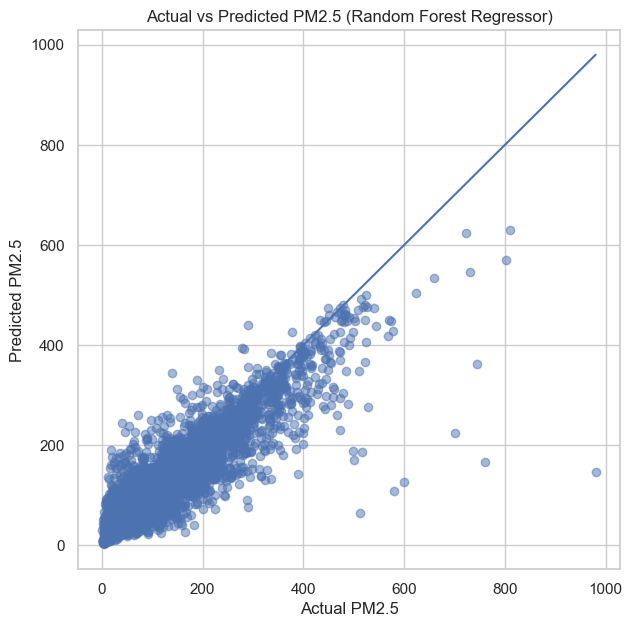

In [67]:
# Actual vs predicted plot for best regression model
best_reg_name = regression_results.iloc[0]["Model"]

if best_reg_name == "Random Forest Regressor":
    best_pred = y_pred_rf
else:
    best_pred = y_pred_lr

plt.figure(figsize=(7, 7))
plt.scatter(y_test_reg, best_pred, alpha=0.5)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title(f"Actual vs Predicted PM2.5 ({best_reg_name})")
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()])
plt.show()


### Regression Interpretation

The model with lower **MAE** and **RMSE**, and higher **R²**, performs better.  
Random Forest often performs better than Linear Regression when the relationship between variables is nonlinear.


## 10. Classification Models for Pollution Risk Analysis

We compare:

1. **Logistic Regression**  
2. **Random Forest Classifier**


In [68]:
# Logistic Regression pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

log_model.fit(X_train_clf, y_train_clf)
y_pred_log = log_model.predict(X_test_clf)

log_acc = accuracy_score(y_test_clf, y_pred_log)
log_precision = precision_score(y_test_clf, y_pred_log, average="weighted")
log_recall = recall_score(y_test_clf, y_pred_log, average="weighted")
log_f1 = f1_score(y_test_clf, y_pred_log, average="weighted")

print("Logistic Regression Results")
print("Accuracy :", round(log_acc, 3))
print("Precision:", round(log_precision, 3))
print("Recall   :", round(log_recall, 3))
print("F1-score :", round(log_f1, 3))


Logistic Regression Results
Accuracy : 0.544
Precision: 0.568
Recall   : 0.544
F1-score : 0.5


In [69]:
# Random Forest Classifier pipeline
rf_clf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = rf_clf_model.predict(X_test_clf)

rf_acc = accuracy_score(y_test_clf, y_pred_clf)
rf_precision = precision_score(y_test_clf, y_pred_clf, average="weighted")
rf_recall = recall_score(y_test_clf, y_pred_clf, average="weighted")
rf_f1 = f1_score(y_test_clf, y_pred_clf, average="weighted")

print("Random Forest Classifier Results")
print("Accuracy :", round(rf_acc, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1-score :", round(rf_f1, 3))


Random Forest Classifier Results
Accuracy : 0.752
Precision: 0.745
Recall   : 0.752
F1-score : 0.746


In [70]:
# Classification model comparison table
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [log_acc, rf_acc],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1]
}).sort_values(by="F1 Score", ascending=False)

classification_results


,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest Classifier,0.751796,0.744626,0.751796,0.745964
0,Logistic Regression,0.544181,0.568415,0.544181,0.499609


In [71]:
# Detailed classification report for best classifier
best_clf_name = classification_results.iloc[0]["Model"]

if best_clf_name == "Random Forest Classifier":
    best_y_pred_clf = y_pred_clf
else:
    best_y_pred_clf = y_pred_log

print(f"Best Classification Model: {best_clf_name}\n")
print(classification_report(y_test_clf, best_y_pred_clf))


Best Classification Model: Random Forest Classifier

              precision    recall  f1-score   support

        High       0.63      0.47      0.54      1275
         Low       0.83      0.88      0.86      3189
    Moderate       0.64      0.64      0.64      2089
   Very High       0.79      0.84      0.81      1799

    accuracy                           0.75      8352
   macro avg       0.72      0.71      0.71      8352
weighted avg       0.74      0.75      0.75      8352



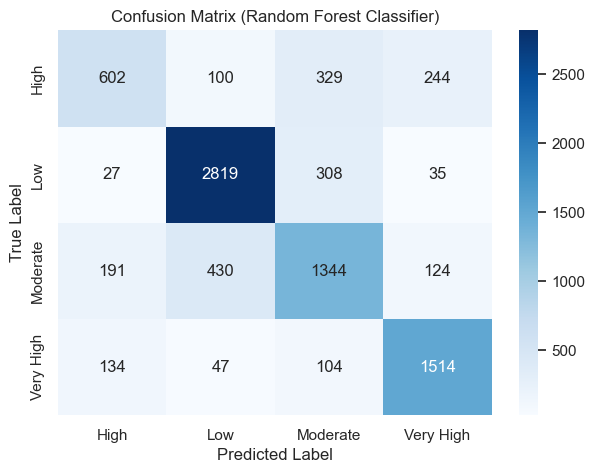

In [72]:
# Confusion matrix for best classifier
cm = confusion_matrix(y_test_clf, best_y_pred_clf, labels=sorted(y_test_clf.unique()))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y_test_clf.unique()),
            yticklabels=sorted(y_test_clf.unique()))
plt.title(f"Confusion Matrix ({best_clf_name})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Classification Interpretation

A higher **accuracy** and **F1-score** indicates stronger classification performance.  
The confusion matrix helps identify which pollution categories are easier or harder for the model to classify.


## 11. Sample Predictions

This section shows how the best models can be used to generate predictions.


In [73]:
sample_rows = X_test_reg.head(10).copy()

# Regression predictions
sample_rows["Actual_PM2.5"] = y_test_reg.head(10).values
sample_rows["Predicted_PM2.5_LR"] = lr_model.predict(X_test_reg.head(10))
sample_rows["Predicted_PM2.5_RF"] = rf_reg_model.predict(X_test_reg.head(10))

sample_rows


,DEWP,TEMP,PRES,Iws,Is,Ir,year,month,day,hour,cbwd,season_name,time_of_day,Actual_PM2.5,Predicted_PM2.5_LR,Predicted_PM2.5_RF
27120,-7,-7.0,1020.0,16.10,0,0,2013,2,4,0,NW,Winter,Night,215.0,172.357332,182.986667
35861,-31,-2.0,1027.0,13.86,0,0,2014,2,3,5,NW,Winter,Night,6.0,-13.131205,11.873333
28100,3,10.0,1020.0,29.05,0,0,2013,3,16,20,SE,Spring,Evening,280.0,138.760328,243.880000
29250,4,21.0,1015.0,12.96,0,0,2013,5,3,18,SE,Spring,Evening,57.0,75.885352,63.420000
34096,-12,11.0,1024.0,2.68,0,0,2013,11,21,16,cv,Autumn,Afternoon,50.0,49.796000,47.713333
26484,-19,-2.0,1031.0,23.25,0,0,2013,1,8,12,NW,Winter,Afternoon,20.0,85.312230,30.780000
36825,-12,8.0,1012.0,1.34,0,0,2014,3,15,9,cv,Spring,Morning,99.0,74.379087,95.266667
10221,-16,3.0,1026.0,60.35,0,0,2011,3,2,21,NW,Spring,Evening,20.0,20.535423,37.900000
19561,-5,5.0,1021.0,3.58,0,0,2012,3,26,1,SE,Spring,Night,130.0,112.936419,98.126667
32597,16,18.0,1015.0,14.30,0,0,2013,9,20,5,NW,Autumn,Night,114.0,131.176853,80.080000


In [74]:
sample_class = X_test_clf.head(10).copy()
sample_class["Actual_Risk"] = y_test_clf.head(10).values
sample_class["Predicted_Risk_Logistic"] = log_model.predict(X_test_clf.head(10))
sample_class["Predicted_Risk_RF"] = rf_clf_model.predict(X_test_clf.head(10))

sample_class


,DEWP,TEMP,PRES,Iws,Is,Ir,year,month,day,hour,cbwd,season_name,time_of_day,Actual_Risk,Predicted_Risk_Logistic,Predicted_Risk_RF
704,-15,-6.0,1021.0,0.89,0,0,2010,1,30,8,cv,Winter,Morning,Low,Very High,Low
43683,-10,-3.0,1033.0,0.89,0,0,2014,12,26,3,SE,Winter,Night,Very High,Very High,Very High
4043,17,23.0,1004.0,0.89,0,0,2010,6,18,11,cv,Summer,Morning,Moderate,Moderate,Moderate
28498,-1,10.0,1021.0,1.79,0,0,2013,4,2,10,cv,Spring,Morning,Very High,Moderate,Moderate
14110,25,27.0,1004.0,26.39,0,0,2011,8,11,22,SE,Summer,Evening,High,Moderate,Very High
7703,-2,0.0,1022.0,0.89,0,0,2010,11,17,23,cv,Autumn,Evening,Very High,Very High,Very High
41546,12,15.0,1017.0,0.89,0,0,2014,9,28,2,cv,Autumn,Night,Moderate,Very High,Moderate
17824,-13,4.0,1026.0,7.15,0,0,2012,1,13,16,SE,Winter,Afternoon,Moderate,Moderate,Very High
41420,18,19.0,1018.0,4.02,0,2,2014,9,22,20,NW,Autumn,Evening,High,Very High,High
20233,13,16.0,1004.0,29.50,0,0,2012,4,23,1,SE,Spring,Night,Very High,Very High,Very High


## 12. Key Findings

- Machine learning can be used effectively for **PM2.5 prediction** and **pollution risk classification**.  
- Environmental and weather-related variables provide meaningful signals for air quality forecasting.  
- Comparing multiple models makes the project stronger and helps identify the most effective approach.


## 13. Conclusion

This project successfully explored air quality forecasting and pollution risk analysis using the Beijing PM2.5 dataset. After cleaning and analyzing the data, both regression and classification models were built to understand pollution behavior.

The regression task estimated PM2.5 concentration, while the classification task translated those values into meaningful pollution risk levels. Comparing multiple models provided a more reliable evaluation of performance. Overall, the project demonstrates how machine learning can support environmental monitoring, decision-making, and public health awareness.


## 14. Future Improvements

Possible extensions for this project include:

- using advanced models such as **XGBoost**, **LightGBM**, or **LSTM**  
- including additional pollutants and external weather data  
- deploying the model in a **dashboard** for interactive prediction  
- adding real-time forecasting and alert systems
